# Trust Duel: Person vs Agent

A reinforcement learning inspired game based on the **Iterated Prisoner's Dilemma**.

The goal is to compare fixed strategies and a learning agent in a repeated decision-making environment.


## 1. Project Introduction

In this project, we model a simple repeated game where each player chooses one of two actions:

- `C` = Cooperate
- `D` = Defect

The reward depends on both players' actions.

This is useful for reinforcement learning because the game has:

| RL Concept | In This Game |
|---|---|
| Agent | Strategy or Q-learning player |
| Environment | Game rules and payoff matrix |
| State | Previous actions |
| Action | Cooperate or Defect |
| Reward | Coins from the payoff matrix |
| Episode | A repeated match |
| Policy | The rule used to choose actions |


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src.game import PAYOFFS, simulate_match, tournament
from src.strategies import (
    AlwaysCooperate,
    AlwaysDefect,
    RandomStrategy,
    TitForTat,
    GrimTrigger,
    TitForTwoTats,
    ForgivingTitForTat,
    SuspiciousTitForTat,
)
from src.q_agent import (
    train_q_agent,
    train_q_agent_against_pool,
    TrainedQAgentStrategy,
)

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 50)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

## 2. Game Rules and Payoff Matrix

The payoff matrix defines the reward for each combination of actions.

- If both cooperate: both get `3`
- If one defects while the other cooperates: defector gets `5`, cooperator gets `0`
- If both defect: both get `1`

The game becomes interesting when it is repeated many times.


In [2]:
payoff_table = pd.DataFrame(
    {
        "Agent Cooperates": ["Human: 3, Agent: 3", "Human: 5, Agent: 0"],
        "Agent Defects": ["Human: 0, Agent: 5", "Human: 1, Agent: 1"],
    },
    index=["Human Cooperates", "Human Defects"],
)

payoff_table


,Agent Cooperates,Agent Defects
Human Cooperates,"Human: 3, Agent: 3","Human: 0, Agent: 5"
Human Defects,"Human: 5, Agent: 0","Human: 1, Agent: 1"


### Interpretation

This payoff matrix is the environment's reward system.

The agent does not receive a label like in supervised learning.  
Instead, it receives a reward after each action pair.

This is why the same game can be interpreted as a Reinforcement Learning problem.

In [3]:
rl_mapping = pd.DataFrame(
    [
        ["Agent", "The player that makes decisions"],
        ["Environment", "The repeated Prisoner's Dilemma game"],
        ["State", "Previous actions of both players"],
        ["Action", "Cooperate (C) or Defect (D)"],
        ["Reward", "Coins received from the payoff matrix"],
        ["Episode", "One full repeated match"],
        ["Policy", "The rule used to choose actions"],
        ["Q-table", "Learned values of actions in different states"],
    ],
    columns=["RL Concept", "Meaning in This Project"],
)

rl_mapping

,RL Concept,Meaning in This Project
0,Agent,The player that makes decisions
1,Environment,The repeated Prisoner's Dilemma game
2,State,Previous actions of both players
3,Action,Cooperate (C) or Defect (D)
4,Reward,Coins received from the payoff matrix
5,Episode,One full repeated match
6,Policy,The rule used to choose actions
7,Q-table,Learned values of actions in different states


## 3. Test One Match

First, we simulate a match between two fixed strategies.

Example:

- Player A: Tit for Tat
- Player B: Always Defect

Tit for Tat starts with cooperation, then copies the opponent's previous action.


In [4]:
match_df = simulate_match(
    TitForTat(),
    AlwaysDefect(),
    rounds=20,
    noise=0.0,
    seed=42,
)

match_df.head(10)


,round,player_a,player_b,intended_a,intended_b,action_a,action_b,reward_a,reward_b,cumulative_a,cumulative_b
0,1,Tit for Tat,Always Defect,C,D,C,D,0,5,0,5
1,2,Tit for Tat,Always Defect,D,D,D,D,1,1,1,6
2,3,Tit for Tat,Always Defect,D,D,D,D,1,1,2,7
3,4,Tit for Tat,Always Defect,D,D,D,D,1,1,3,8
4,5,Tit for Tat,Always Defect,D,D,D,D,1,1,4,9
5,6,Tit for Tat,Always Defect,D,D,D,D,1,1,5,10
6,7,Tit for Tat,Always Defect,D,D,D,D,1,1,6,11
7,8,Tit for Tat,Always Defect,D,D,D,D,1,1,7,12
8,9,Tit for Tat,Always Defect,D,D,D,D,1,1,8,13
9,10,Tit for Tat,Always Defect,D,D,D,D,1,1,9,14


In [5]:
match_df.tail()


,round,player_a,player_b,intended_a,intended_b,action_a,action_b,reward_a,reward_b,cumulative_a,cumulative_b
15,16,Tit for Tat,Always Defect,D,D,D,D,1,1,15,20
16,17,Tit for Tat,Always Defect,D,D,D,D,1,1,16,21
17,18,Tit for Tat,Always Defect,D,D,D,D,1,1,17,22
18,19,Tit for Tat,Always Defect,D,D,D,D,1,1,18,23
19,20,Tit for Tat,Always Defect,D,D,D,D,1,1,19,24


## 4. Fixed Strategy Tournament

Now we compare several strategies in a round-robin tournament.

This gives us the algorithm-vs-algorithm version of the game.


In [6]:
strategies = [
    AlwaysCooperate(),
    AlwaysDefect(),
    RandomStrategy(p_defect=0.5, seed=42),
    TitForTat(),
    GrimTrigger(),
    TitForTwoTats(),
    ForgivingTitForTat(forgiveness=0.1, seed=42),
    SuspiciousTitForTat(),
]

strategy_guide = pd.DataFrame(
    [
        [
            "Always Cooperate",
            "Always plays C",
            "Friendly",
            "Can get good mutual rewards, but can be exploited by defectors.",
        ],
        [
            "Always Defect",
            "Always plays D",
            "Aggressive",
            "Can exploit naive opponents, but often causes low mutual rewards.",
        ],
        [
            "Random",
            "Randomly chooses C or D",
            "Unpredictable",
            "Useful as a baseline because it has no stable policy.",
        ],
        [
            "Tit for Tat",
            "Starts with C, then copies the opponent's previous move",
            "Reciprocal",
            "Strong because it is clear, responsive, and forgiving.",
        ],
        [
            "Grim Trigger",
            "Starts with C, but after one opponent defection defects forever",
            "Strict",
            "Punishes betrayal strongly, but cannot recover from mistakes or noise.",
        ],
        [
            "Tit for Two Tats",
            "Defects only after two consecutive opponent defections",
            "Tolerant",
            "More forgiving than Tit for Tat and less sensitive to one mistake.",
        ],
        [
            "Forgiving Tit for Tat",
            "Copies defection but sometimes forgives",
            "Flexible",
            "Can perform better in noisy environments because it can repair cooperation.",
        ],
        [
            "Suspicious Tit for Tat",
            "Starts with D, then copies the opponent's previous move",
            "Defensive",
            "Tests how much the first move affects long-term trust.",
        ],
    ],
    columns=["Strategy", "Rule", "Behavior", "Interpretation"],
)

strategy_guide

,Strategy,Rule,Behavior,Interpretation
0,Always Cooperate,Always plays C,Friendly,"Can get good mutual rewards, but can be exploited by defectors."
1,Always Defect,Always plays D,Aggressive,"Can exploit naive opponents, but often causes low mutual rewards."
2,Random,Randomly chooses C or D,Unpredictable,Useful as a baseline because it has no stable policy.
3,Tit for Tat,"Starts with C, then copies the opponent's previous move",Reciprocal,"Strong because it is clear, responsive, and forgiving."
4,Grim Trigger,"Starts with C, but after one opponent defection defects forever",Strict,"Punishes betrayal strongly, but cannot recover from mistakes or noise."
5,Tit for Two Tats,Defects only after two consecutive opponent defections,Tolerant,More forgiving than Tit for Tat and less sensitive to one mistake.
6,Forgiving Tit for Tat,Copies defection but sometimes forgives,Flexible,Can perform better in noisy environments because it can repair cooperation.
7,Suspicious Tit for Tat,"Starts with D, then copies the opponent's previous move",Defensive,Tests how much the first move affects long-term trust.


### Strategy Explanation

The strategies are intentionally simple.

This is important because the goal is not to hide the logic inside a complex model.  
The goal is to compare different decision rules and observe how they perform in repeated interaction.

Some strategies are cooperative, some are aggressive, and some are reactive.

In [7]:
ranking, matches = tournament(
    strategies,
    rounds=200,
    noise=0.0,
    include_self=True,
    seed=42,
)

ranking

,rank,strategy,total_score,average_score_per_match_round
0,1,Forgiving Tit for Tat,4802,3.001250
1,2,Tit for Two Tats,4758,2.973750
2,3,Tit for Tat,4741,2.963125
3,4,Grim Trigger,4583,2.864375
4,5,Always Cooperate,4485,2.803125
5,6,Random,3804,2.377500
6,7,Suspicious Tit for Tat,3549,2.218125
7,8,Always Defect,3076,1.922500


## 5. Tournament Visualization

The ranking chart shows which strategy collected the most total reward across all matches.


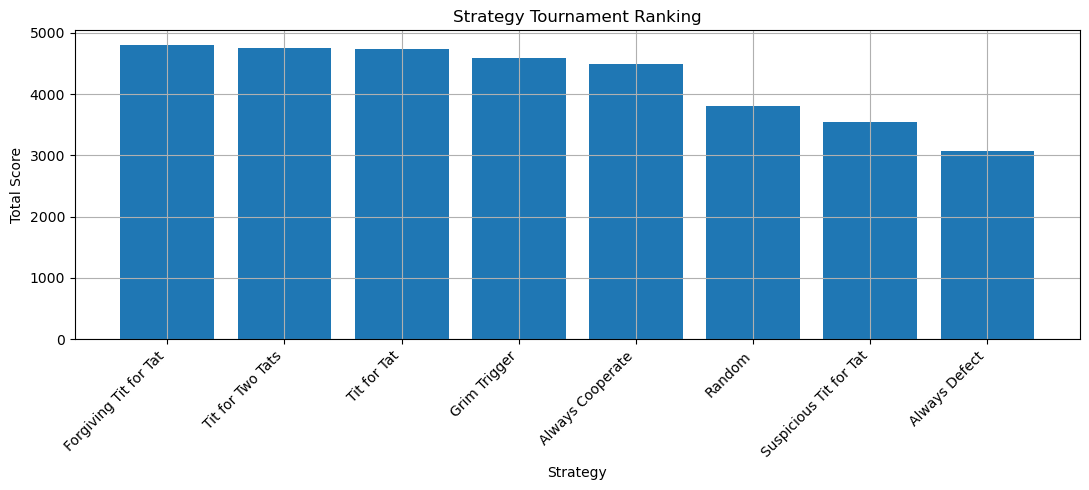

WindowsPath('C:/Users/viktus/Desktop/for_labs/trust-duel-rl-game/reports/figures/strategy_tournament_ranking.png')

In [8]:
plt.figure(figsize=(11, 5))
plt.bar(ranking["strategy"], ranking["total_score"])
plt.title("Strategy Tournament Ranking")
plt.xlabel("Strategy")
plt.ylabel("Total Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

ranking_path = FIGURES_DIR / "strategy_tournament_ranking.png"
plt.savefig(ranking_path, dpi=150)
plt.show()

ranking_path

### Interpretation

This chart shows the total score of each fixed strategy in the tournament.

A high score means that the strategy performed well across many opponents, not only against one specific opponent.

This is important because in repeated games there is no universally best strategy.  
A strategy is strong only relative to the environment and the opponents it faces.

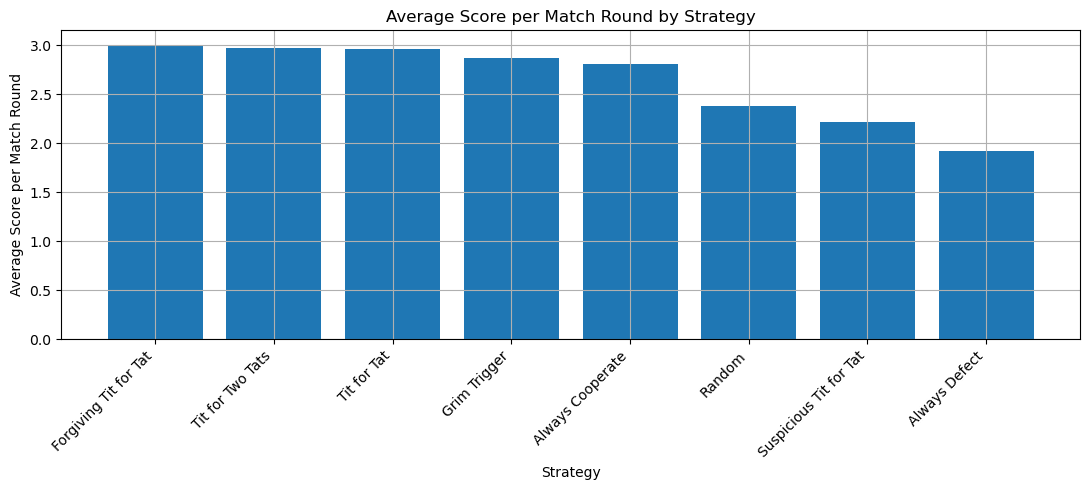

,rank,strategy,average_score_per_match_round
0,1,Forgiving Tit for Tat,3.001250
1,2,Tit for Two Tats,2.973750
2,3,Tit for Tat,2.963125
3,4,Grim Trigger,2.864375
4,5,Always Cooperate,2.803125
5,6,Random,2.377500
6,7,Suspicious Tit for Tat,2.218125
7,8,Always Defect,1.922500


In [9]:
plt.figure(figsize=(11, 5))
plt.bar(ranking["strategy"], ranking["average_score_per_match_round"])
plt.title("Average Score per Match Round by Strategy")
plt.xlabel("Strategy")
plt.ylabel("Average Score per Match Round")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

avg_ranking_path = FIGURES_DIR / "average_score_per_match_round.png"
plt.savefig(avg_ranking_path, dpi=150)
plt.show()

ranking[["rank", "strategy", "average_score_per_match_round"]]

### Interpretation

The average score per match round is easier to understand than the total score.

For example, an average close to `3` means that the strategy often reaches mutual cooperation.  
An average close to `1` means that the strategy often falls into mutual defection or low-reward situations.

## 6. Cumulative Reward Example

A cumulative reward chart helps us see how performance changes over repeated rounds.


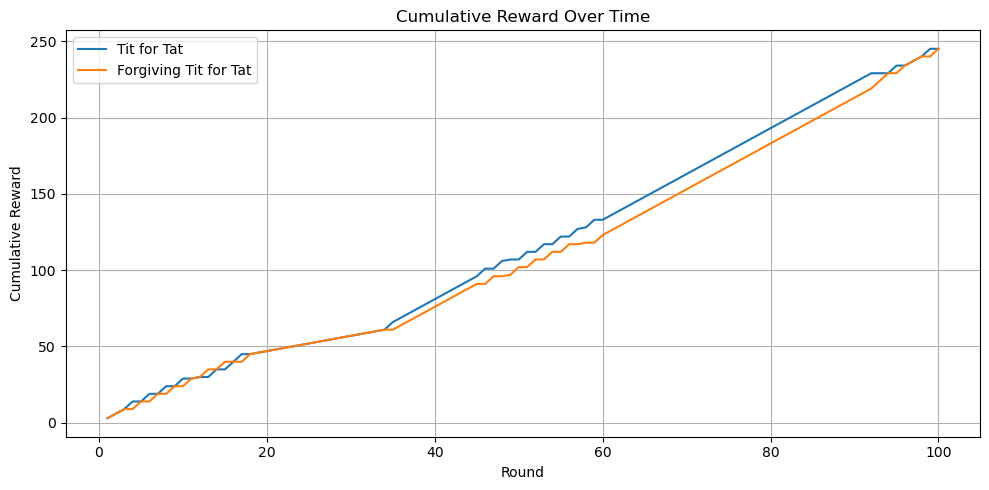

,round,player_a,player_b,intended_a,intended_b,action_a,action_b,reward_a,reward_b,cumulative_a,cumulative_b
95,96,Tit for Tat,Forgiving Tit for Tat,C,D,C,D,0,5,234,234
96,97,Tit for Tat,Forgiving Tit for Tat,D,C,C,C,3,3,237,237
97,98,Tit for Tat,Forgiving Tit for Tat,C,C,C,C,3,3,240,240
98,99,Tit for Tat,Forgiving Tit for Tat,C,C,D,C,5,0,245,240
99,100,Tit for Tat,Forgiving Tit for Tat,C,D,C,D,0,5,245,245


In [10]:
example_match = simulate_match(
    TitForTat(),
    ForgivingTitForTat(forgiveness=0.1, seed=7),
    rounds=100,
    noise=0.05,
    seed=7,
)

plt.figure(figsize=(10, 5))
plt.plot(example_match["round"], example_match["cumulative_a"], label="Tit for Tat")
plt.plot(example_match["round"], example_match["cumulative_b"], label="Forgiving Tit for Tat")
plt.title("Cumulative Reward Over Time")
plt.xlabel("Round")
plt.ylabel("Cumulative Reward")
plt.legend()
plt.tight_layout()

cumulative_path = FIGURES_DIR / "cumulative_reward_example.png"
plt.savefig(cumulative_path, dpi=150)
plt.show()

example_match.tail()


### Interpretation

The cumulative reward chart shows how rewards grow over repeated rounds.

If both lines grow steadily and stay close, it usually means the strategies are cooperating successfully.

If one line grows much faster, it means one strategy is exploiting the other.

If both lines grow slowly, it usually means the game has fallen into mutual defection or unstable behavior.

In [11]:
example_match[
    [
        "round",
        "player_a",
        "player_b",
        "action_a",
        "action_b",
        "reward_a",
        "reward_b",
        "cumulative_a",
        "cumulative_b",
    ]
].head(15)

,round,player_a,player_b,action_a,action_b,reward_a,reward_b,cumulative_a,cumulative_b
0,1,Tit for Tat,Forgiving Tit for Tat,C,C,3,3,3,3
1,2,Tit for Tat,Forgiving Tit for Tat,C,C,3,3,6,6
2,3,Tit for Tat,Forgiving Tit for Tat,C,C,3,3,9,9
3,4,Tit for Tat,Forgiving Tit for Tat,D,C,5,0,14,9
4,5,Tit for Tat,Forgiving Tit for Tat,C,D,0,5,14,14
5,6,Tit for Tat,Forgiving Tit for Tat,D,C,5,0,19,14
6,7,Tit for Tat,Forgiving Tit for Tat,C,D,0,5,19,19
7,8,Tit for Tat,Forgiving Tit for Tat,D,C,5,0,24,19
8,9,Tit for Tat,Forgiving Tit for Tat,C,D,0,5,24,24
9,10,Tit for Tat,Forgiving Tit for Tat,D,C,5,0,29,24


### What This Table Shows

This table shows the actual round-by-round interaction.

The line chart gives the big picture, while this table explains what happened inside the game:

- which actions were chosen,
- what rewards were received,
- how the cumulative score changed.

## 7. Human vs Agent Game

This is the person-vs-agent part.

The function below lets a human play against a fixed strategy agent.

In a normal notebook, run the cell and type:

- `C` for cooperate
- `D` for defect


In [12]:
def play_human_vs_agent(agent_strategy, rounds=10):
    human_history = []
    agent_history = []
    human_score = 0
    agent_score = 0

    print(f"You are playing against: {agent_strategy.name}")
    print("Type C to cooperate or D to defect.\n")

    for round_idx in range(1, rounds + 1):
        human_action = input(f"Round {round_idx} — Your action (C/D): ").strip().upper()

        while human_action not in ["C", "D"]:
            human_action = input("Invalid input. Please type C or D: ").strip().upper()

        agent_action = agent_strategy.choose_action(agent_history, human_history)

        reward_human, reward_agent = PAYOFFS[(human_action, agent_action)]

        human_history.append(human_action)
        agent_history.append(agent_action)

        human_score += reward_human
        agent_score += reward_agent

        print(
            f"Human: {human_action} | Agent: {agent_action} "
            f"| Reward: Human {reward_human}, Agent {reward_agent} "
            f"| Total: Human {human_score}, Agent {agent_score}"
        )

    return pd.DataFrame(
        {
            "round": range(1, rounds + 1),
            "human_action": human_history,
            "agent_action": agent_history,
        }
    )

# Uncomment to play:
# human_game = play_human_vs_agent(TitForTat(), rounds=10)
# human_game


## 8. Q-Learning Agent

Now we train a simple tabular Q-learning agent.

The agent does not follow a manually written strategy like Tit for Tat.  
Instead, it learns action values from experience.

The Q-agent observes a simple state:

```text
state = (my_previous_action, opponent_previous_action)
```
Then it chooses one of two actions:
```text
C = Cooperate
D = Defect
```
After each round, the agent receives a reward from the payoff matrix and updates its Q-table.

The Q-learning update is:

Q(s, a) ← Q(s, a) + alpha * [reward + gamma * max(Q(next_state)) - Q(s, a)]

Key parameters:

Parameter	Meaning
alpha	Learning rate. Controls how strongly new information updates old Q-values.
gamma	Discount factor. Controls how much the agent cares about future reward.
epsilon	Exploration rate. Controls how often the agent chooses a random action.
epsilon_decay	Reduces exploration after each episode.
epsilon_min	Minimum exploration level.

In [13]:
agent, training_log = train_q_agent(
    opponent_strategy=TitForTat(),
    episodes=1000,
    rounds_per_episode=100,
    seed=42,
)

training_log["avg_reward_per_round"] = training_log["total_reward"] / 100

training_log.head()

,episode,total_reward,epsilon,avg_reward_per_round
0,1,240,0.995000,2.40
1,2,240,0.990025,2.40
2,3,225,0.985075,2.25
3,4,239,0.980150,2.39
4,5,221,0.975249,2.21


### Training Log Explanation

Each row represents one training episode.

One episode contains 100 repeated rounds.

Columns:

- `episode`: number of the training episode
- `total_reward`: total reward collected by the Q-agent during that episode
- `epsilon`: exploration rate after the episode
- `avg_reward_per_round`: average reward per round in that episode

The average reward per round is easier to interpret than the total reward.

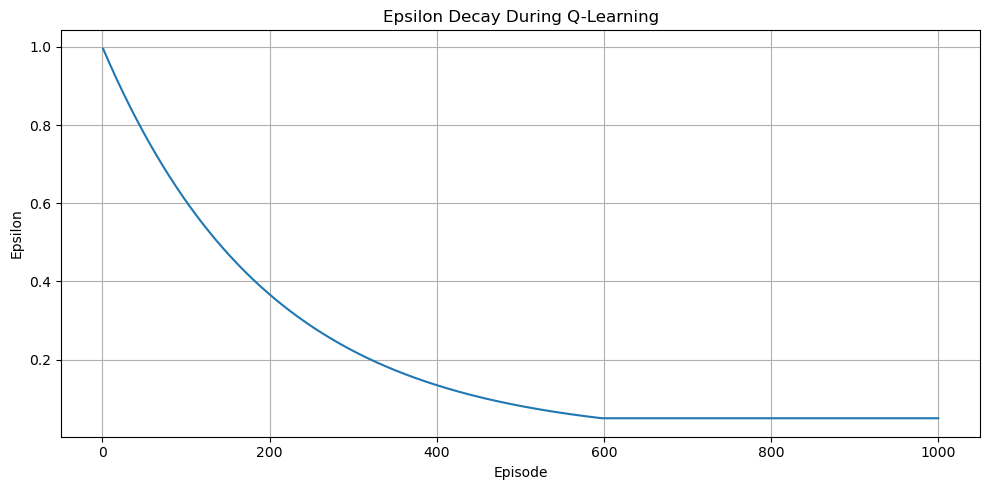

WindowsPath('C:/Users/viktus/Desktop/for_labs/trust-duel-rl-game/reports/figures/epsilon_decay_single_opponent.png')

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(training_log["episode"], training_log["epsilon"])
plt.title("Epsilon Decay During Q-Learning")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.tight_layout()

epsilon_path = FIGURES_DIR / "epsilon_decay_single_opponent.png"
plt.savefig(epsilon_path, dpi=150)
plt.show()

epsilon_path

### Interpretation

Epsilon controls exploration.

At the beginning, epsilon is high, so the agent often chooses random actions.  
As training continues, epsilon decreases, so the agent relies more on learned Q-values.

This is the exploration-exploitation tradeoff:

- early training: more exploration,
- later training: more exploitation.

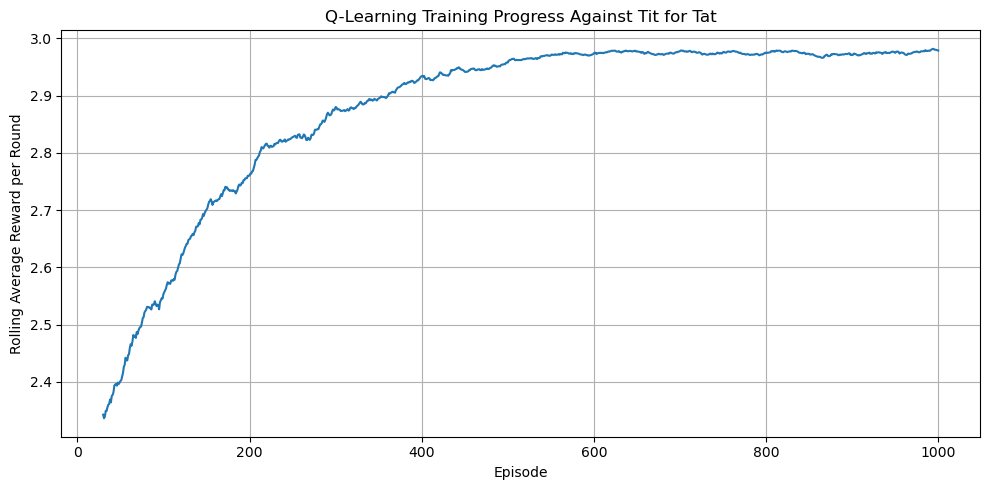

,episode,total_reward,epsilon,avg_reward_per_round
995,996,296,0.05,2.96
996,997,299,0.05,2.99
997,998,298,0.05,2.98
998,999,298,0.05,2.98
999,1000,296,0.05,2.96


In [15]:
plt.figure(figsize=(10, 5))
plt.plot(
    training_log["episode"],
    training_log["avg_reward_per_round"].rolling(30).mean(),
)
plt.title("Q-Learning Training Progress Against Tit for Tat")
plt.xlabel("Episode")
plt.ylabel("Rolling Average Reward per Round")
plt.tight_layout()

training_path = FIGURES_DIR / "q_learning_training_progress.png"
plt.savefig(training_path, dpi=150)
plt.show()

training_log.tail()

### Interpretation

This chart shows whether the Q-agent improves during training.

The rolling average smooths short-term randomness and makes the learning trend easier to see.

If the line increases or stabilizes at a reasonable reward level, it means the agent has learned a useful policy against this opponent.

## 9. Inspect the Q-Table

The Q-table stores the learned value of each action in each state.

Higher Q-value means the agent expects higher future reward from that action.


In [16]:
q_table_df = agent.q_table_dataframe()
q_table_df


,state_my_previous,state_opponent_previous,Q_C,Q_D,best_action
0,START,START,60.0,59.149454,C
1,D,C,57.0,55.150000,C
2,C,D,60.0,59.150000,C
3,C,C,60.0,59.150000,C
4,D,D,57.0,55.150000,C


### Q-Table Explanation

The Q-table stores the expected value of each action in each state.

- `Q_C` means the learned value of cooperating in that state.
- `Q_D` means the learned value of defecting in that state.
- `best_action` shows which action currently has the higher Q-value.

This is the learned policy of the Q-agent.

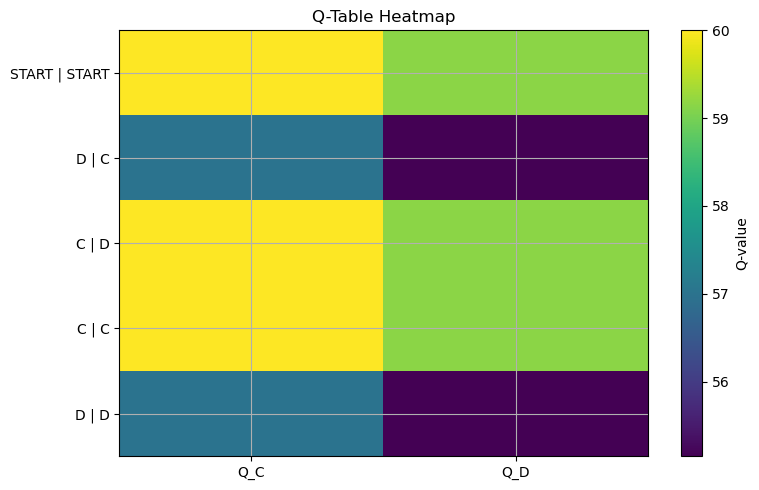

,Q_C,Q_D
state,,
START | START,60.0,59.149454
D | C,57.0,55.150000
C | D,60.0,59.150000
C | C,60.0,59.150000
D | D,57.0,55.150000


In [17]:
q_vis = q_table_df.copy()
q_vis["state"] = (
    q_vis["state_my_previous"] + " | " + q_vis["state_opponent_previous"]
)

q_values = q_vis.set_index("state")[["Q_C", "Q_D"]]

plt.figure(figsize=(8, 5))
plt.imshow(q_values.values, aspect="auto")
plt.colorbar(label="Q-value")
plt.xticks(range(2), ["Q_C", "Q_D"])
plt.yticks(range(len(q_values.index)), q_values.index)
plt.title("Q-Table Heatmap")
plt.tight_layout()

q_heatmap_path = FIGURES_DIR / "q_table_heatmap_single_opponent.png"
plt.savefig(q_heatmap_path, dpi=150)
plt.show()

q_values

### Interpretation

The heatmap makes the Q-table easier to explain visually.

Brighter or stronger values indicate that the agent expects higher reward from that action in that state.

If `Q_D` is higher than `Q_C` in a state, the agent prefers defection there.  
If `Q_C` is higher than `Q_D`, the agent prefers cooperation.

## 10. Evaluate Trained Q-Agent

Now we wrap the trained Q-learning agent as a strategy and let it play a normal match.


In [18]:
trained_q_strategy = TrainedQAgentStrategy(agent)

q_eval_match = simulate_match(
    trained_q_strategy,
    TitForTat(),
    rounds=100,
    noise=0.0,
    seed=123,
)

q_eval_match.tail()


,round,player_a,player_b,intended_a,intended_b,action_a,action_b,reward_a,reward_b,cumulative_a,cumulative_b
95,96,Trained Q-Agent,Tit for Tat,C,C,C,C,3,3,288,288
96,97,Trained Q-Agent,Tit for Tat,C,C,C,C,3,3,291,291
97,98,Trained Q-Agent,Tit for Tat,C,C,C,C,3,3,294,294
98,99,Trained Q-Agent,Tit for Tat,C,C,C,C,3,3,297,297
99,100,Trained Q-Agent,Tit for Tat,C,C,C,C,3,3,300,300


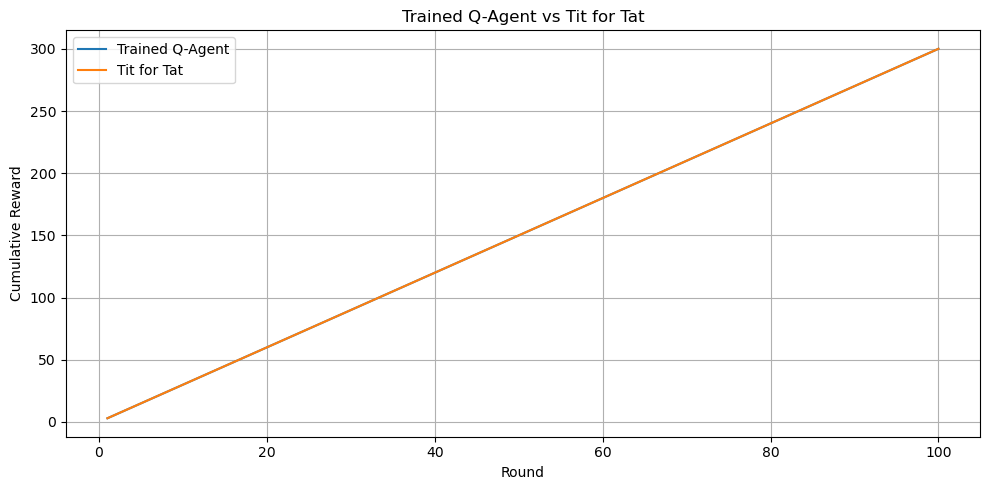

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(q_eval_match["round"], q_eval_match["cumulative_a"], label="Trained Q-Agent")
plt.plot(q_eval_match["round"], q_eval_match["cumulative_b"], label="Tit for Tat")
plt.title("Trained Q-Agent vs Tit for Tat")
plt.xlabel("Round")
plt.ylabel("Cumulative Reward")
plt.legend()
plt.tight_layout()

q_eval_path = FIGURES_DIR / "trained_q_agent_vs_tit_for_tat.png"
plt.savefig(q_eval_path, dpi=150)
plt.show()


## 11. Train Q-Agent Against a Pool of Strategies

Training against one opponent can make the Q-agent too specialized.

To make training more general, we train the agent against a pool of different strategies.

In the improved version, the opponent selection is balanced.  
This means each strategy appears roughly the same number of times during training.

This makes the result easier to explain and reduces bias toward one repeated opponent.

In [20]:
pool = [
    AlwaysCooperate(),
    AlwaysDefect(),
    RandomStrategy(p_defect=0.5, seed=42),
    TitForTat(),
    GrimTrigger(),
    ForgivingTitForTat(forgiveness=0.1, seed=42),
]

rounds_per_episode = 100

pool_agent, pool_training_log = train_q_agent_against_pool(
    pool,
    episodes=1500,
    rounds_per_episode=rounds_per_episode,
    seed=42,
)

pool_training_log["avg_reward_per_round"] = (
    pool_training_log["total_reward"] / rounds_per_episode
)

pool_training_log.head(10)

,episode,total_reward,epsilon,opponent,avg_reward_per_round
0,1,240.0,0.995000,Tit for Tat,2.40
1,2,205.0,0.990025,Random,2.05
2,3,234.0,0.985075,Forgiving Tit for Tat,2.34
3,4,66.0,0.980150,Grim Trigger,0.66
4,5,50.0,0.975249,Always Defect,0.50
5,6,400.0,0.970373,Always Cooperate,4.00
6,7,211.0,0.965521,Random,2.11
7,8,55.0,0.960693,Grim Trigger,0.55
8,9,396.0,0.955890,Always Cooperate,3.96
9,10,58.0,0.951110,Always Defect,0.58


### Pool Training Log Explanation

Each row is one training episode.

The `opponent` column shows which fixed strategy the Q-agent faced in that episode.

The same opponent may appear again in later episodes because training happens across many repeated episodes.  
In the balanced version, each strategy appears approximately the same number of times overall.

The `epsilon` column shows how much the agent is still exploring.

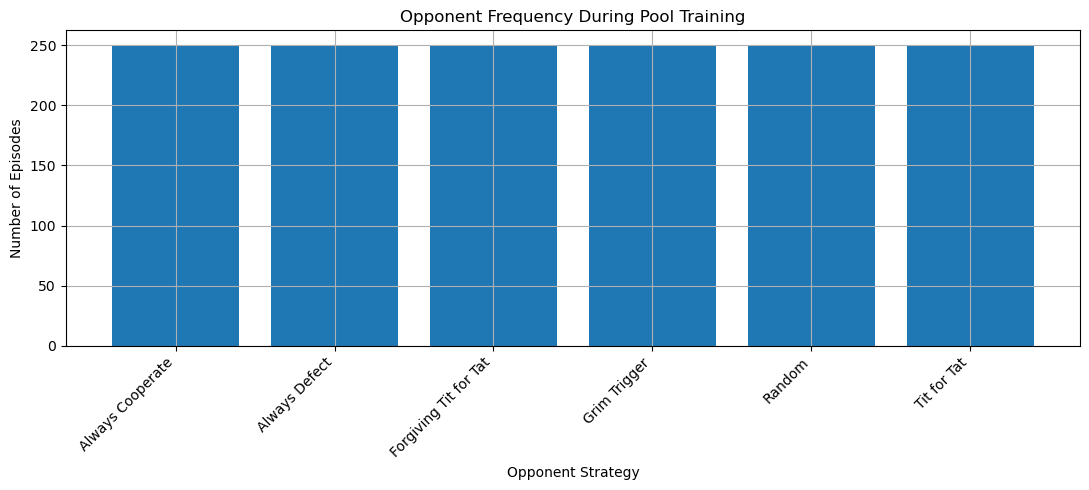

opponent
Always Cooperate         250
Always Defect            250
Forgiving Tit for Tat    250
Grim Trigger             250
Random                   250
Tit for Tat              250
Name: count, dtype: int64

In [21]:
opponent_counts = pool_training_log["opponent"].value_counts().sort_index()

plt.figure(figsize=(11, 5))
plt.bar(opponent_counts.index, opponent_counts.values)
plt.title("Opponent Frequency During Pool Training")
plt.xlabel("Opponent Strategy")
plt.ylabel("Number of Episodes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

opponent_frequency_path = FIGURES_DIR / "opponent_frequency_pool_training.png"
plt.savefig(opponent_frequency_path, dpi=150)
plt.show()

opponent_counts

### Interpretation

This chart shows how often each opponent appeared during pool training.

A balanced distribution is useful because the Q-agent gets experience against different types of behavior:

- cooperative,
- aggressive,
- random,
- reactive,
- forgiving,
- unforgiving.

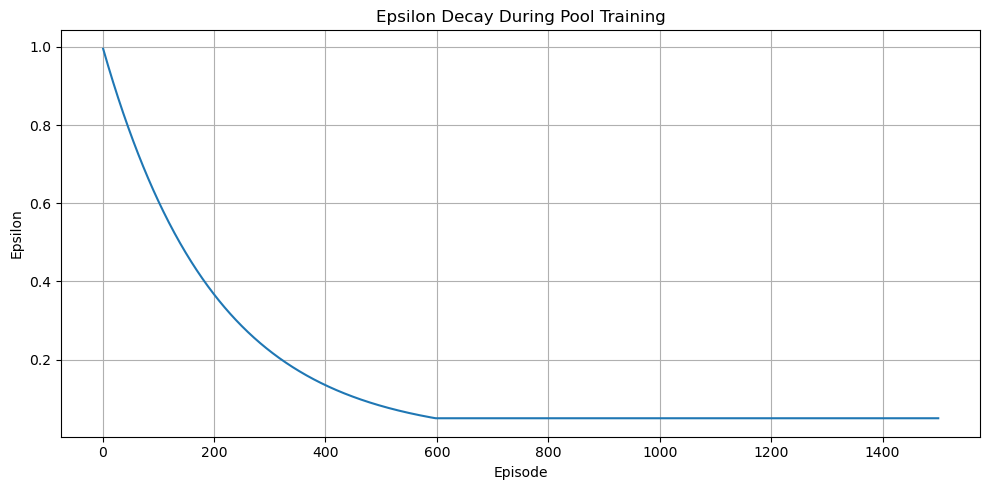

WindowsPath('C:/Users/viktus/Desktop/for_labs/trust-duel-rl-game/reports/figures/epsilon_decay_pool_training.png')

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(pool_training_log["episode"], pool_training_log["epsilon"])
plt.title("Epsilon Decay During Pool Training")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.tight_layout()

pool_epsilon_path = FIGURES_DIR / "epsilon_decay_pool_training.png"
plt.savefig(pool_epsilon_path, dpi=150)
plt.show()

pool_epsilon_path

### Interpretation

This chart shows the exploration schedule of the Q-agent.

At the beginning, the agent explores heavily.  
Later, it uses the Q-table more often.

This is why early results can look unstable: the agent is still experimenting.

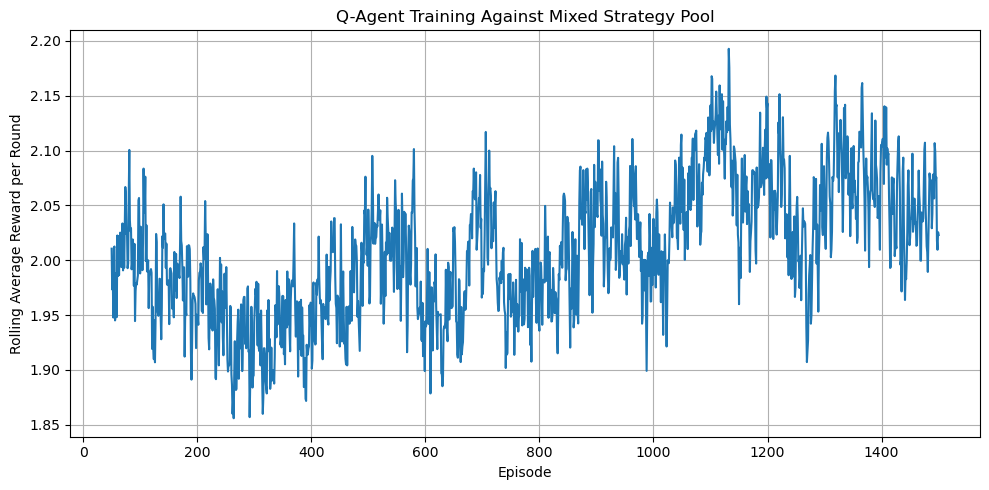

,episode,total_reward,epsilon,opponent,avg_reward_per_round
1495,1496,308.0,0.05,Always Cooperate,3.08
1496,1497,23.0,0.05,Always Defect,0.23
1497,1498,224.0,0.05,Grim Trigger,2.24
1498,1499,276.0,0.05,Forgiving Tit for Tat,2.76
1499,1500,276.0,0.05,Tit for Tat,2.76


In [23]:
plt.figure(figsize=(10, 5))
plt.plot(
    pool_training_log["episode"],
    pool_training_log["avg_reward_per_round"].rolling(50).mean(),
)
plt.title("Q-Agent Training Against Mixed Strategy Pool")
plt.xlabel("Episode")
plt.ylabel("Rolling Average Reward per Round")
plt.tight_layout()

pool_training_path = FIGURES_DIR / "q_agent_pool_training.png"
plt.savefig(pool_training_path, dpi=150)
plt.show()

pool_training_log.tail()

### Interpretation

This chart shows the Q-agent's performance during mixed-opponent training.

Because the opponent changes between episodes, the reward is naturally more unstable than single-opponent training.

The rolling average helps reveal the general trend.

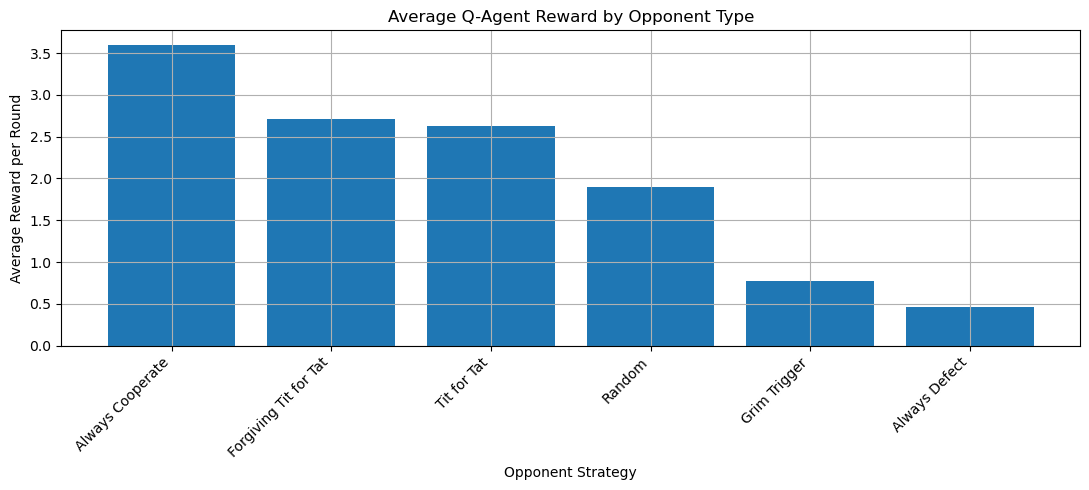

opponent
Always Cooperate         3.59176
Forgiving Tit for Tat    2.70576
Tit for Tat              2.62488
Random                   1.89400
Grim Trigger             0.77140
Always Defect            0.46268
Name: avg_reward_per_round, dtype: float64

In [24]:
avg_by_opponent = (
    pool_training_log.groupby("opponent")["avg_reward_per_round"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(11, 5))
plt.bar(avg_by_opponent.index, avg_by_opponent.values)
plt.title("Average Q-Agent Reward by Opponent Type")
plt.xlabel("Opponent Strategy")
plt.ylabel("Average Reward per Round")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

avg_by_opponent_path = FIGURES_DIR / "average_reward_by_opponent.png"
plt.savefig(avg_by_opponent_path, dpi=150)
plt.show()

avg_by_opponent

### Interpretation

This chart shows which opponents are easier or harder for the Q-agent.

High average reward means the agent found a profitable way to play against that strategy.

Low average reward usually means the opponent is defensive, aggressive, or difficult to exploit.

In [25]:
pool_q_table_df = pool_agent.q_table_dataframe()
pool_q_table_df

,state_my_previous,state_opponent_previous,Q_C,Q_D,best_action
0,START,START,47.919163,45.775936,C
1,D,C,39.047247,36.444457,C
2,C,D,33.314085,41.565604,D
3,C,C,55.195540,43.412962,C
4,D,D,33.838831,30.372246,C


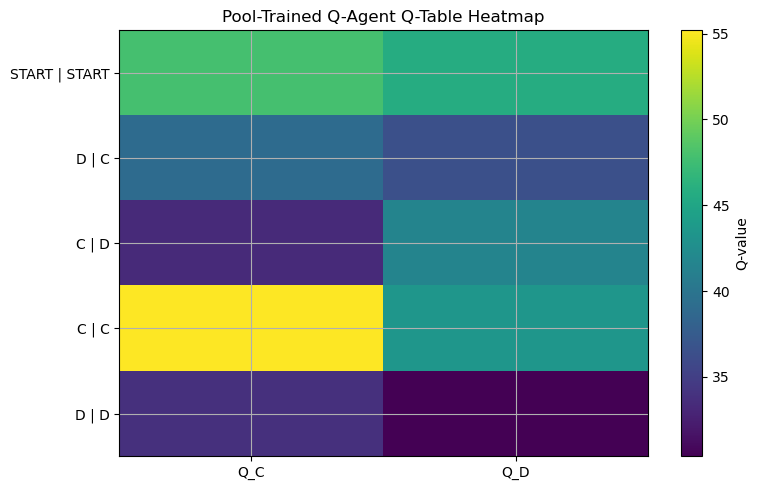

,Q_C,Q_D
state,,
START | START,47.919163,45.775936
D | C,39.047247,36.444457
C | D,33.314085,41.565604
C | C,55.195540,43.412962
D | D,33.838831,30.372246


In [26]:
pool_q_vis = pool_q_table_df.copy()
pool_q_vis["state"] = (
    pool_q_vis["state_my_previous"] + " | " + pool_q_vis["state_opponent_previous"]
)

pool_q_values = pool_q_vis.set_index("state")[["Q_C", "Q_D"]]

plt.figure(figsize=(8, 5))
plt.imshow(pool_q_values.values, aspect="auto")
plt.colorbar(label="Q-value")
plt.xticks(range(2), ["Q_C", "Q_D"])
plt.yticks(range(len(pool_q_values.index)), pool_q_values.index)
plt.title("Pool-Trained Q-Agent Q-Table Heatmap")
plt.tight_layout()

pool_q_heatmap_path = FIGURES_DIR / "q_table_heatmap_pool_agent.png"
plt.savefig(pool_q_heatmap_path, dpi=150)
plt.show()

pool_q_values

### Interpretation

This heatmap shows the policy learned after training against multiple opponents.

Compared with single-opponent training, this Q-table should represent a more general strategy.

The agent is not learning morality.  
It is learning which action gives better expected reward in each observed state.

In [27]:
project_summary = pd.DataFrame(
    [
        ["Game type", "Iterated Prisoner's Dilemma"],
        ["Main actions", "Cooperate (C), Defect (D)"],
        ["Main RL agent", "Tabular Q-learning agent"],
        ["State representation", "(my_previous_action, opponent_previous_action)"],
        ["Reward source", "Payoff matrix"],
        ["Training type 1", "Single-opponent training"],
        ["Training type 2", "Balanced pool training"],
        ["Main insight", "Strategy performance depends on opponent behavior and environment"],
    ],
    columns=["Component", "Description"],
)

project_summary

,Component,Description
0,Game type,Iterated Prisoner's Dilemma
1,Main actions,"Cooperate (C), Defect (D)"
2,Main RL agent,Tabular Q-learning agent
3,State representation,"(my_previous_action, opponent_previous_action)"
4,Reward source,Payoff matrix
5,Training type 1,Single-opponent training
6,Training type 2,Balanced pool training
7,Main insight,Strategy performance depends on opponent behavior and environment


### Final Project Summary

This table summarizes the full project in one place.

It can be used as a presentation slide or as a quick explanation for the project logic.

## 12. Final Interpretation

This project demonstrates Reinforcement Learning through a repeated decision-making game.

The fixed-strategy tournament shows that simple strategies can perform very differently depending on the opponents.

The Q-learning agent shows a different approach: instead of following a manually written rule, it learns action values from repeated rewards.

Main conclusions:

1. **There is no universally best strategy.**  
   A strategy can perform well in one environment and poorly in another.

2. **Cooperation can be valuable in repeated games.**  
   Mutual cooperation gives both players stable rewards.

3. **Defection can exploit weak opponents.**  
   However, against retaliatory opponents, it can lead to low long-term reward.

4. **Forgiveness matters when there is noise.**  
   If one mistake permanently destroys cooperation, both players may lose reward over time.

5. **Q-learning connects the game to RL.**  
   The agent observes a state, chooses an action, receives a reward, and updates its Q-table.

Final idea:

```text
Repeated interaction turns a simple game into a learning environment.
The agent does not need to understand trust or morality.
It only needs states, actions, rewards, and repeated experience.